# ENJL — one T = 0 beta-equilibrium line, timed, checked, and phase-labelled

The extended Nambu–Jona-Lasinio model of

> C.-J. Xia, *Extended NJL model for baryonic matter and quark matter*,
> Phys. Rev. D **110**, 014022 (2024), arXiv:2405.02946

A baryon here is a three-quark cluster whose mass is built from the same
constituent masses the NJL gap equation determines, so confinement,
quarkyonic matter and deconfinement come out of **one** mean field. The
quantity that says which of the three a density is in is

> `chi = n_B^Q / n_B`

the fraction of the baryon density carried by *deconfined* quarks — the `fq`
column of the author's own tables. `chi = 0` is confined baryonic matter,
`0 < chi < 1` is quarkyonic (quasi-free quarks alongside surviving baryons),
`chi = 1` is deconfined quark matter.

What this notebook does, in order:

1. solves `beta_eq_neutrinoless` at `T = 0` on **300 densities**, warm-started
   point by point, and times **every point** as well as the total;
2. labels each density confined / quarkyonic / deconfined;
3. checks the line against the author's reference tables;
4. plots `P`, `Y_i`, `M*_i` and the rest through `eos.general.figure_style`.

Units are the ones every public boundary uses: `n` in fm^-3, `mu` and masses
in MeV, `P` and `eps` in MeV/fm^3. Strangeness is `S = +1` per s quark.

In [1]:
import sys
import time
from pathlib import Path

import numpy as np

ROOT = Path.cwd()
if not (ROOT / "eos").is_dir():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt

import eos.enjl as enjl
from eos.enjl.solver import warm_start
from eos.enjl.table import beta_row
from eos.general.figure_style import (LABELS, OKAB_CAT, log_decades,
                                      panel_label, paper_grid, particle_style)
from eos.general.sound_speeds import sound_speed_eq

## The knobs

Every choice this notebook makes, and no cell below reaches past this one for
a number. `Parameters.named` returns one of the six published `(f_q, B)`
combinations of the study — parameters are arguments, never module state.
`SpeciesFlags()` needs no arguments: this model's species set is *fixed*
(p, n, Lambda, u, d, s, e, mu) and moving a flag raises rather than being
quietly ignored, so the defaults already are the model.

The grid stops at 4 fm^-3 because that is past the deconfinement transition of
every published set, and starts at 0.05 fm^-3 because below that the uniform
matter this model describes is not the physical state anyway.

In [2]:
SET = "fq0.5_B1"                       # f_q = 0.5, B = 1 GeV/fm^3 (the default)
N_B = np.linspace(0.05, 4.0, 300)      # fm^-3 — 300 points
T = 0.0                                # MeV
MODE = "beta_eq_neutrinoless"

PAR = enjl.Parameters.named(SET)
SPECIES = enjl.SpeciesFlags()

print(f"ENJL {SET}:  f_q = {PAR.f_q},  B = {PAR.B_GeV_fm3} GeV/fm^3")
print(f"species: {SPECIES}")
print(f"grid: {len(N_B)} points, {N_B[0]:.3f} -> {N_B[-1]:.3f} fm^-3, "
      f"T = {T} MeV")

ENJL fq0.5_B1:  f_q = 0.5,  B = 1.0 GeV/fm^3
species: SpeciesFlags(hyperons=True, muons=True, deltas=False, thermal_mesons=False, photons=False, thermal_neutrinos=False)
grid: 300 points, 0.050 -> 4.000 fm^-3, T = 0.0 MeV


## 1. The line, one point at a time, timed

`eos_table` would solve the same grid in one call, but its progress callback
fires once per *line* and this notebook wants the cost of a *point*. So the
continuation is written out: each converged point seeds the next through
`solver.warm_start`, which is exactly what `eos_table(direction="up")` does
internally — the counts below match it.

**Non-convergence is a return value.** A refused density comes back as
`PointResult(ok=False)` and is counted, not raised: past the first-order
transition the low-density branch runs out, which is physics about the model
and not a solver failure.

In [3]:
rows, times, refused = [], [], []
x0 = None

start_total = time.perf_counter()
for n_B in N_B:
    start = time.perf_counter()
    result = enjl.eos_point(PAR, MODE, SPECIES, n_B=float(n_B), T=T, x0=x0)
    times.append(time.perf_counter() - start)
    if result.ok:
        rows.append(beta_row(result.point))
        x0 = warm_start(result.point)
    else:
        refused.append((float(n_B), result.message))
total_s = time.perf_counter() - start_total

times = np.asarray(times)
print(f"total            {total_s:8.3f} s   for {len(N_B)} requested points")
print(f"converged        {len(rows):8d}     "
      f"({len(refused)} refused)")
print(f"per point  mean  {1e3 * times.mean():8.2f} ms")
print(f"           median{1e3 * np.median(times):8.2f} ms")
print(f"           min   {1e3 * times.min():8.2f} ms   "
      f"(cold start: {1e3 * times[0]:.1f} ms)")
print(f"           max   {1e3 * times.max():8.2f} ms   "
      f"at n_B = {N_B[times.argmax()]:.3f} fm^-3")
for n_B, message in refused[:5]:
    print(f"  refused n_B = {n_B:.3f}: {message[:70]}")

total               1.548 s   for 300 requested points
converged             295     (5 refused)
per point  mean      5.15 ms
           median    3.58 ms
           min       2.88 ms   (cold start: 137.3 ms)
           max     137.29 ms   at n_B = 0.050 fm^-3
  refused n_B = 3.947: ENJL beta_eq_neutrinoless solve did not converge at n_B=3.9472 fm^-3 a
  refused n_B = 3.960: ENJL beta_eq_neutrinoless solve did not converge at n_B=3.9604 fm^-3 a
  refused n_B = 3.974: ENJL beta_eq_neutrinoless solve did not converge at n_B=3.9736 fm^-3 a
  refused n_B = 3.987: ENJL beta_eq_neutrinoless solve did not converge at n_B=3.9868 fm^-3 a
  refused n_B = 4.000: ENJL beta_eq_neutrinoless solve did not converge at n_B=4.0000 fm^-3 a


### Rows to columns

`beta_row` gives the flat, fm-based row: `P`, `eps`, `s`, the four potentials,
the eight species densities, the six constituent masses, and `chi`. One dict
per converged point, in density order, so a column is one comprehension.

In [4]:
COL = {key: np.array([row[key] for row in rows]) for key in rows[0]}
COL["cs2"] = sound_speed_eq(COL["P"], COL["eps"])
for species in ("p", "n", "Lambda", "u", "d", "s", "e", "mu"):
    COL[f"Y_{species}"] = COL[f"n_{species}"] / COL["n_B"]

print(f"{len(COL['n_B'])} rows, {len(COL)} columns")
print(f"n_B  {COL['n_B'][0]:.3f} -> {COL['n_B'][-1]:.3f} fm^-3")
print(f"P    {COL['P'][0]:.3f} -> {COL['P'][-1]:.1f} MeV/fm^3")
print(f"chi  {COL['chi'][0]:.3e} -> {COL['chi'][-1]:.4f}")

295 rows, 36 columns
n_B  0.050 -> 3.934 fm^-3
P    0.138 -> 11801.0 MeV/fm^3
chi  0.000e+00 -> 0.2297


## 2. The phases

`chi = n_B^Q / n_B` is the fraction of the baryon density carried by
deconfined quarks, so it *is* the phase label:

| `chi` | phase | what is there |
|---|---|---|
| `~ 0` | **confined** | baryons only; the quarks are bound inside them |
| `0 < chi < 1` | **quarkyonic** | quasi-free quarks *and* surviving baryons |
| `~ 1` | **deconfined** | the baryons have dissolved |

The threshold below is a numerical zero, not a physical one: `chi` leaves zero
by tunnelling-small amounts (`1e-50` in the author's own tables) long before
there is any quark matter to speak of, so a bare `chi > 0` would call the
whole line quarkyonic.

In [5]:
CHI_FLOOR = 1.0e-4      # below this, no quark population worth the name
CHI_CEIL = 1.0 - 1e-6   # above this, no baryon left


def phase_of(chi):
    """confined / quarkyonic / deconfined, from chi = n_B^Q / n_B."""
    if chi < CHI_FLOOR:
        return "confined"
    if chi > CHI_CEIL:
        return "deconfined"
    return "quarkyonic"


def windows(n_B, labels):
    """[(phase, n_lo, n_hi)] — consecutive runs of one label."""
    out = []
    for n, label in zip(n_B, labels):
        if out and out[-1][0] == label:
            out[-1][2] = n
        else:
            out.append([label, n, n])
    return [(label, lo, hi) for label, lo, hi in out]


COL["phase"] = np.array([phase_of(chi) for chi in COL["chi"]])

print(f"--- the {MODE} branch continued up from {N_B[0]} fm^-3 ---")
for label, lo, hi in windows(COL["n_B"], COL["phase"]):
    inside = (COL["n_B"] >= lo) & (COL["n_B"] <= hi)
    print(f"  {label:11s} n_B = {lo:5.3f} -> {hi:5.3f} fm^-3   "
          f"({inside.sum():3d} pts)   "
          f"chi {COL['chi'][inside].min():.4f} -> "
          f"{COL['chi'][inside].max():.4f}")

--- the beta_eq_neutrinoless branch continued up from 0.05 fm^-3 ---
  confined    n_B = 0.050 -> 0.156 fm^-3   (  9 pts)   chi 0.0000 -> 0.0000
  quarkyonic  n_B = 0.169 -> 3.934 fm^-3   (286 pts)   chi 0.0007 -> 0.2297


### The deconfined branch, and where the physical EoS switches to it

The sweep above follows **one branch**. Past a first-order transition it keeps
following it into the metastable region, which is why it never reaches
`chi = 1`: the deconfined state is a *different* root of the same
thermodynamic potential at the same potentials, and no continuation from below
lands on it. `eos_table(direction="down")` seeds from a deconfined guess at
the top of the grid instead and comes back down — that is the second branch.

Choosing between them is a Maxwell construction: **at fixed `mu_B` the stable
phase is the one with the larger `P`.** Applied point by point on the two
swept branches, that costs an interpolation and no further solves. The last
switch — the one above which the deconfined branch stays ahead — is
deconfinement, and it is first order: the two branches sit at different
densities at the one `mu_B`, and that density gap is the coexistence window.

This locates the window to the resolution of the grid, which is what a
notebook wants; `eos.mixed.construction.enjl_coexistences` is the exact
locator, and `eos_table(..., coexistences=...)` is what turns the window into
a delivered constant-pressure table for a structure solver.

In [6]:
start = time.perf_counter()
down_rows = enjl.eos_table(PAR, MODE, SPECIES, {"nB": N_B, "T": [T]},
                           direction="down", rows=True)
down_s = time.perf_counter() - start

DOWN = {key: np.array([row[key] for row in down_rows]) for key in down_rows[0]}
DOWN["phase"] = np.array([phase_of(chi) for chi in DOWN["chi"]])

print(f"down branch: {down_s:.2f} s, {len(down_rows)}/{len(N_B)} points, "
      f"{1e3 * down_s / len(down_rows):.2f} ms/pt")
for label, lo, hi in windows(DOWN["n_B"], DOWN["phase"]):
    print(f"  {label:11s} n_B = {lo:5.3f} -> {hi:5.3f} fm^-3")

# The Maxwell comparison, on the mu_B interval both branches cover.
mu_lo = max(COL["mu_B"].min(), DOWN["mu_B"].min())
mu_hi = min(COL["mu_B"].max(), DOWN["mu_B"].max())
mu_grid = np.linspace(mu_lo, mu_hi, 4000)
P_up = np.interp(mu_grid, COL["mu_B"], COL["P"])
P_down = np.interp(mu_grid, DOWN["mu_B"], DOWN["P"])

crossings = np.where(np.diff(np.sign(P_down - P_up)) != 0)[0]
if len(crossings) == 0:
    print("\nno branch crossing on this grid — no transition to construct")
    MU_T = N_LO = N_HI = None
    SEQUENCE = windows(COL["n_B"], COL["phase"])
else:
    MU_T = mu_grid[crossings[-1]]
    N_LO = np.interp(MU_T, COL["mu_B"], COL["n_B"])
    N_HI = np.interp(MU_T, DOWN["mu_B"], DOWN["n_B"])
    below, above = COL["n_B"] <= N_LO, DOWN["n_B"] >= N_HI
    SEQUENCE = (windows(COL["n_B"][below], COL["phase"][below])
                + [("coexistence", N_LO, N_HI)]
                + windows(DOWN["n_B"][above], DOWN["phase"][above]))
    print(f"\ndeconfinement (Maxwell, largest P at fixed mu_B):")
    print(f"  mu_B  = {MU_T:.1f} MeV")
    print(f"  P     = {np.interp(MU_T, mu_grid, P_up):.1f} MeV/fm^3")
    print(f"  n_B   = {N_LO:.3f} -> {N_HI:.3f} fm^-3   "
          f"(coexistence window, first order)")

#: The physical sequence: the stable branch either side of the window, and the
#: window itself. Printed here and shaded behind every figure below.
print(f"\nSo the physical T = 0 beta-equilibrium sequence of {SET} is")
for label, lo, hi in SEQUENCE:
    plateau = "  (constant P — a Maxwell plateau)" if label == "coexistence" \
        else ""
    print(f"  {label:11s} {lo:5.3f} -> {hi:5.3f} fm^-3{plateau}")

down branch: 15.25 s, 233/300 points, 65.45 ms/pt
  quarkyonic  n_B = 0.222 -> 0.327 fm^-3
  deconfined  n_B = 1.001 -> 3.947 fm^-3

deconfinement (Maxwell, largest P at fixed mu_B):
  mu_B  = 2297.6 MeV
  P     = 1120.7 MeV/fm^3
  n_B   = 1.255 -> 1.869 fm^-3   (coexistence window, first order)

So the physical T = 0 beta-equilibrium sequence of fq0.5_B1 is
  confined    0.050 -> 0.156 fm^-3
  quarkyonic  0.169 -> 1.252 fm^-3
  coexistence 1.255 -> 1.869 fm^-3  (constant P — a Maxwell plateau)
  deconfined  1.873 -> 3.947 fm^-3


## 3. Against the author's own tables

`test/enjl/reference/` holds five beta-equilibrium tables produced by the
author's Maple implementation — the code that made the paper's figures, so
they pin the model far tighter than the two or three significant figures the
paper prints. They are **golden references**: code that disagrees with them is
wrong until proven otherwise, so the residual is printed rather than
summarised as "agrees".

Four things about the columns matter and are handled below:

* `E` is the energy density with the vacuum term already subtracted, so it is
  directly our `eps`; `fq` is directly our `chi`.
* **`munr`, not `mun`, is the baryon chemical potential** — they part company
  by hundreds of MeV once the baryons have dissolved.
* A blank `munr` marks a row that is linear interpolation across the author's
  own Maxwell plateau rather than solver output; those rows are masked out.
* The comparison stops below the coexistence window located above, because
  past it the author's table follows the *construction* and this notebook's
  line follows a *branch* — comparing those two measures nothing.

`test/` is gitignored, so a fresh clone has neither the tables nor a loader
for them; this cell parses the `.dat` itself and reports absence as a message
rather than a traceback.

In [7]:
REFERENCE = ROOT / "test" / "enjl" / "reference" / f"Beta_{SET}.dat"
#: our column -> the author's column name
AUTHOR_COLUMN = {"P": "P", "eps": "E", "mu_B": "munr", "mu_e": "mue",
                 "chi": "fq", "n_p": "np", "n_n": "nn", "M_u": "Mu",
                 "M_s": "Ms"}

if not REFERENCE.is_file():
    print(f"{REFERENCE} absent — `test/` is gitignored, so a fresh clone has "
          f"no author tables. Nothing to compare against.")
else:
    with open(REFERENCE) as handle:
        names = [c.strip() for c in handle.readline().rstrip("\n").split("\t")]
    raw = np.genfromtxt(REFERENCE, delimiter="\t", skip_header=1,
                        missing_values="--", filling_values=np.nan)
    author = {name: raw[:, i].astype(float) for i, name in enumerate(names)
              if name and not name.startswith("Derivative")}
    solved = np.isfinite(author["nB"]) & np.isfinite(author["munr"])
    author = {key: value[solved] for key, value in author.items()}

    # The author's own densities, so nothing is interpolated on either side,
    # and below the transition, where both sides are the same object.
    ceiling = N_LO if N_LO is not None else author["nB"].max()
    window = (author["nB"] >= N_B[0]) & (author["nB"] <= ceiling)
    grid = author["nB"][window]
    print(f"{REFERENCE.name}: {solved.sum()} solved rows, comparing on "
          f"{len(grid)} of them, n_B = {grid[0]:.2f} -> {grid[-1]:.2f} fm^-3")

    ours = enjl.eos_table(PAR, MODE, SPECIES, {"nB": grid, "T": [T]},
                          direction="up", rows=True)
    ours = {round(row["n_B"], 9): row for row in ours}
    hit = np.array([round(n, 9) in ours for n in grid])
    print(f"{hit.sum()}/{len(grid)} solved here\n")

    print(f"{'column':8s} {'max |rel|':>10s} {'median |rel|':>13s}   "
          f"{'at n_B':>7s}")
    for key, author_key in AUTHOR_COLUMN.items():
        mine = np.array([ours[round(n, 9)][key] for n in grid[hit]])
        theirs = author[author_key][window][hit]
        scale = np.maximum(np.abs(theirs), np.abs(mine))
        # A relative residual is only meaningful where the quantity is
        # actually there. `chi` is exactly zero here and 1e-16 in the author's
        # run through the whole confined region, which differs by 100% and by
        # nothing; six decades below the column's own maximum is the floor.
        good = scale > 1e-6 * np.abs(theirs).max()
        rel = np.abs(mine - theirs)[good] / scale[good]
        worst = grid[hit][good][rel.argmax()]
        print(f"{key:8s} {rel.max():10.2e} {np.median(rel):13.2e}   "
              f"{worst:7.3f}")

Beta_fq0.5_B1.dat: 180 solved rows, comparing on 106 of them, n_B = 0.05 -> 1.24 fm^-3
106/106 solved here

column    max |rel|  median |rel|    at n_B
P          1.27e-05      4.43e-07     0.070
eps        1.75e-07      1.25e-07     1.240
mu_B       2.18e-07      2.07e-07     1.240
mu_e       2.61e-07      1.32e-08     0.320
chi        4.95e-05      3.74e-07     0.170
n_p        1.20e-06      8.91e-09     0.220
n_n        5.59e-07      8.57e-08     0.630
M_u        2.76e-07      0.00e+00     0.320
M_s        6.71e-08      4.24e-09     0.630


## 4. Figures

Paper style throughout, from `eos.general.figure_style` — the one home for
publication styling in this repository. Every density panel is shaded with the
**physical sequence** located above — confined, quarkyonic, the coexistence
window, deconfined — so the same boundary is read the same way in every
figure, and a curve can be seen leaving the phase it belongs to.

In [8]:
PHASE_BAND = {"confined": "#0072B2", "quarkyonic": "#E69F00",
              "coexistence": "#9a9a9a", "deconfined": "#D55E00"}

#: LaTeX for the species names, so a legend reads Lambda and mu as symbols.
SYMBOL = {"p": "p", "n": "n", "Lambda": r"\Lambda",
          "u": "u", "d": "d", "s": "s", "e": "e", "mu": r"\mu"}


def shade_phases(ax, alpha=0.11):
    """The physical sequence as faint bands behind the curves."""
    for label, lo, hi in SEQUENCE:
        ax.axvspan(lo, hi, color=PHASE_BAND[label], alpha=alpha, lw=0,
                   zorder=0)


def broken(x, y, step=3.0):
    """(x, y) with a NaN inserted wherever the density jumps a solved gap.

    The down branch does not converge at every density, so two consecutive rows
    can sit far apart. A line drawn straight across that gap would claim a
    solution where there is none.
    """
    x, y = np.asarray(x, float), np.asarray(y, float)
    gaps = np.where(np.diff(x) > step * np.diff(N_B).mean())[0] + 1
    return np.insert(x, gaps, np.nan), np.insert(y, gaps, np.nan)


def phase_legend(ax, **kwargs):
    """One key per band actually present in the sequence."""
    seen = dict.fromkeys(label for label, _, _ in SEQUENCE)
    ax.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=PHASE_BAND[label],
                                     alpha=0.35, label=label)
                       for label in seen], **kwargs)

### The equation of state

`P` and `eps` against `n_B`, the equilibrium sound speed `c_e^2 = dP/deps`
along the sequence, and `chi` itself — the panel that *is* the phase diagram
of this line. The dashed curves are the deconfined branch coming down, so the
two roots of the one functional are on the same axes: past the grey
coexistence band the solid curve is the metastable one and the dashed curve is
the physical state. `P` dips near 0.46 fm^-3 and `c_e^2` touches zero with it
— a raw branch may violate `dP/dn_B >= 0`, mechanical instability is real
physics, and it is a construction rather than a branch map that resolves it
before a table reaches a structure solver.

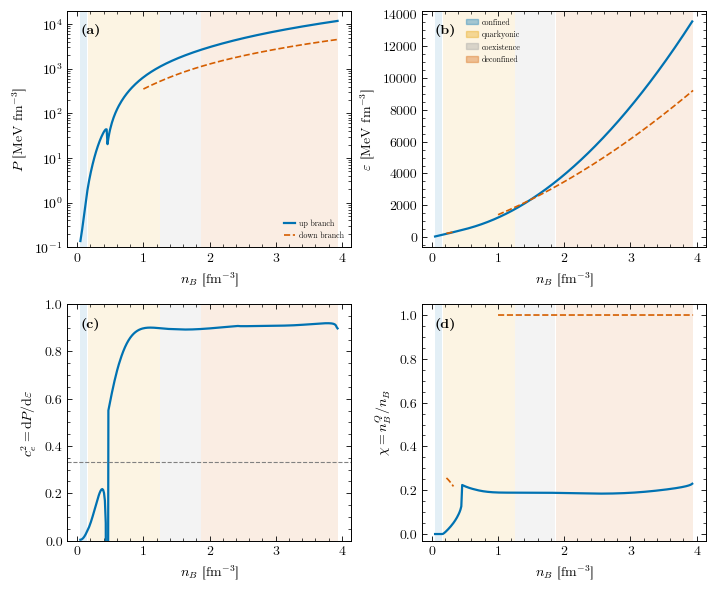

In [9]:
fig, ((ax_P, ax_eps), (ax_cs2, ax_chi)) = paper_grid("2x2", mode="double",
                                                     placeholder=False)

for ax in (ax_P, ax_eps, ax_cs2, ax_chi):
    shade_phases(ax)

ax_P.plot(COL["n_B"], COL["P"], color=OKAB_CAT[0], lw=1.6, label="up branch")
ax_P.plot(*broken(DOWN["n_B"], DOWN["P"]), color=OKAB_CAT[3], lw=1.2, ls="--",
          label="down branch")
ax_P.set_xlabel(LABELS["nB"])
ax_P.set_ylabel(LABELS["P"])
ax_P.set_yscale("log")
ax_P.set_ylim(1e-1, 2e4)
log_decades(ax_P, axis="y")
ax_P.legend(loc="lower right", fontsize="xx-small")

ax_eps.plot(COL["n_B"], COL["eps"], color=OKAB_CAT[0], lw=1.6)
ax_eps.plot(*broken(DOWN["n_B"], DOWN["eps"]), color=OKAB_CAT[3], lw=1.2,
            ls="--")
ax_eps.set_xlabel(LABELS["nB"])
ax_eps.set_ylabel(LABELS["epsilon"])
phase_legend(ax_eps, loc="upper left", fontsize="xx-small",
             bbox_to_anchor=(0.13, 1.0))

ax_cs2.plot(COL["n_B"], COL["cs2"], color=OKAB_CAT[0], lw=1.6)
ax_cs2.axhline(1.0 / 3.0, color="0.5", ls="--", lw=0.8)
ax_cs2.set_xlabel(LABELS["nB"])
ax_cs2.set_ylabel(r"$c_e^2 = \mathrm{d}P/\mathrm{d}\varepsilon$")
ax_cs2.set_ylim(0.0, 1.0)

ax_chi.plot(COL["n_B"], COL["chi"], color=OKAB_CAT[0], lw=1.6)
ax_chi.plot(*broken(DOWN["n_B"], DOWN["chi"]), color=OKAB_CAT[3], lw=1.2,
            ls="--")
ax_chi.set_xlabel(LABELS["nB"])
ax_chi.set_ylabel(r"$\chi = n_B^Q / n_B$")
ax_chi.set_ylim(-0.03, 1.05)

for ax, lab in zip((ax_P, ax_eps, ax_cs2, ax_chi), "abcd"):
    panel_label(ax, f"({lab})")
plt.show()

### Composition

`Y_i = n_i / n_B` for all eight species, with `figure_style`'s particle
colours and linestyles: solid nucleons, dashed Lambda, dash-dot quarks, dotted
leptons. The right panel is the same thing summed into the two families the
phase label is about — the baryons carry `1 - chi` of the baryon number and
the deconfined quarks carry `chi`.

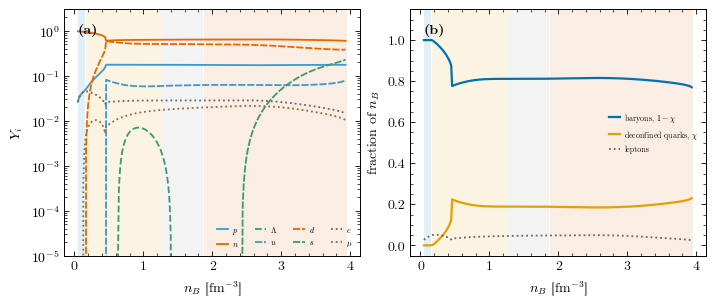

In [10]:
fig, axes = paper_grid("1x2", mode="double", placeholder=False)
ax_Y, ax_family = axes.ravel()

for ax in (ax_Y, ax_family):
    shade_phases(ax)

for species in ("p", "n", "Lambda", "u", "d", "s", "e", "mu"):
    colour, linestyle = particle_style("mu-" if species == "mu" else species)
    ax_Y.plot(COL["n_B"], np.maximum(COL[f"Y_{species}"], 1e-30), color=colour,
              ls=linestyle, lw=1.3, label=rf"${SYMBOL[species]}$")
ax_Y.set_xlabel(LABELS["nB"])
ax_Y.set_ylabel(LABELS["Y_i"])
ax_Y.set_yscale("log")
ax_Y.set_ylim(1e-5, 3.0)
log_decades(ax_Y, axis="y")
ax_Y.legend(loc="lower right", ncol=4, fontsize="xx-small")

baryon = COL["Y_p"] + COL["Y_n"] + COL["Y_Lambda"]
ax_family.plot(COL["n_B"], baryon, color=OKAB_CAT[0], lw=1.6,
               label=r"baryons, $1-\chi$")
ax_family.plot(COL["n_B"], COL["chi"], color=OKAB_CAT[1], lw=1.6,
               label=r"deconfined quarks, $\chi$")
ax_family.plot(COL["n_B"], COL["Y_e"] + COL["Y_mu"], color="0.4", ls=":",
               lw=1.3, label="leptons")
ax_family.set_xlabel(LABELS["nB"])
ax_family.set_ylabel("fraction of $n_B$")
ax_family.set_ylim(-0.05, 1.15)
ax_family.legend(loc="center right", fontsize="xx-small")

for ax, lab in zip((ax_Y, ax_family), "ab"):
    panel_label(ax, f"({lab})")
plt.show()

### Effective masses and chemical potentials

The left panel is what makes this one model rather than two: the constituent
quark masses `M_u`, `M_d`, `M_s` from the gap equation, and the baryon masses
`M_p`, `M_n`, `M_Lambda` *built out of them* by the three-quark cluster
formula. Chiral restoration is the light masses collapsing to their current
values; deconfinement is the Pauli-blocking term driving the baryon masses up
until the clusters unbind.

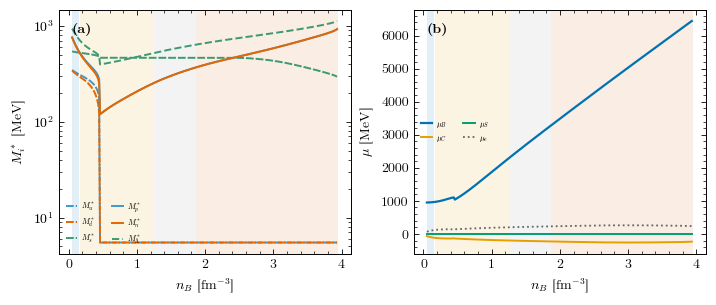

In [11]:
fig, axes = paper_grid("1x2", mode="double", placeholder=False)
ax_M, ax_mu = axes.ravel()

for ax in (ax_M, ax_mu):
    shade_phases(ax)

for species in ("u", "d", "s", "p", "n", "Lambda"):
    colour, linestyle = particle_style(species)
    ax_M.plot(COL["n_B"], COL[f"M_{species}"], color=colour, ls=linestyle,
              lw=1.4, label=rf"$M^*_{{{SYMBOL[species]}}}$")
ax_M.set_xlabel(LABELS["nB"])
ax_M.set_ylabel(r"$M^*_i$ [MeV]")
ax_M.set_yscale("log")
log_decades(ax_M, axis="y")
ax_M.legend(loc="lower left", ncol=2, fontsize="xx-small")

ax_mu.plot(COL["n_B"], COL["mu_B"], color=OKAB_CAT[0], lw=1.6,
           label=r"$\mu_B$")
ax_mu.plot(COL["n_B"], COL["mu_C"], color=OKAB_CAT[1], lw=1.4,
           label=r"$\mu_C$")
ax_mu.plot(COL["n_B"], COL["mu_S"], color=OKAB_CAT[2], lw=1.4,
           label=r"$\mu_S$")
ax_mu.plot(COL["n_B"], COL["mu_e"], color="0.4", ls=":", lw=1.3,
           label=r"$\mu_e$")
ax_mu.set_xlabel(LABELS["nB"])
ax_mu.set_ylabel(r"$\mu$ [MeV]")
ax_mu.legend(loc="center left", ncol=2, fontsize="xx-small")

for ax, lab in zip((ax_M, ax_mu), "ab"):
    panel_label(ax, f"({lab})")
plt.show()

### What a point costs

The per-point wall time of section 1 against the density it was solved at.
The first point is the cold start — no warm start exists yet — and the spikes
are where the continuation has to work, which is where the composition
changes fastest. Both are visible against the same phase bands as every other
figure, which is the point of plotting it here rather than as a number.

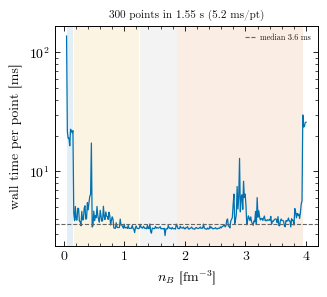

In [12]:
fig, axes = paper_grid("1x1", mode="single", placeholder=False)
ax = axes.ravel()[0]
shade_phases(ax)
ax.plot(N_B, 1e3 * times, color=OKAB_CAT[0], lw=0.9)
ax.axhline(1e3 * np.median(times), color="0.4", ls="--", lw=0.8,
           label=f"median {1e3 * np.median(times):.1f} ms")
ax.set_xlabel(LABELS["nB"])
ax.set_ylabel("wall time per point [ms]")
ax.set_yscale("log")
log_decades(ax, axis="y")
ax.legend(loc="upper right", fontsize="xx-small")
ax.set_title(f"{len(N_B)} points in {total_s:.2f} s "
             f"({1e3 * total_s / len(N_B):.1f} ms/pt)", fontsize=8)
plt.show()